## **Variables correlation**

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
EEA = pd.read_csv('reduced_EEA_2023.csv')

In [3]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Engine_Capacity(cm3),Engine_Power(kW)
0,1175.0,129.0,petrol,999.0,70.0
1,1122.0,117.0,petrol,999.0,59.0
2,1588.0,126.0,diesel,1968.0,110.0
3,1516.0,124.0,diesel,1968.0,110.0
4,1349.0,126.0,petrol,1498.0,110.0


In [4]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75530 entries, 0 to 75529
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Mass_in_Running_Order(kg)  75530 non-null  float64
 1   CO2_Emissions_WLTP(g/km)   75530 non-null  float64
 2   Fuel_Type                  75530 non-null  object 
 3   Engine_Capacity(cm3)       75530 non-null  float64
 4   Engine_Power(kW)           75530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 2.9+ MB


So, we have 4 numerical values and one categorical

we should look at the distribution of our numerical features so we can know which scaler to apply

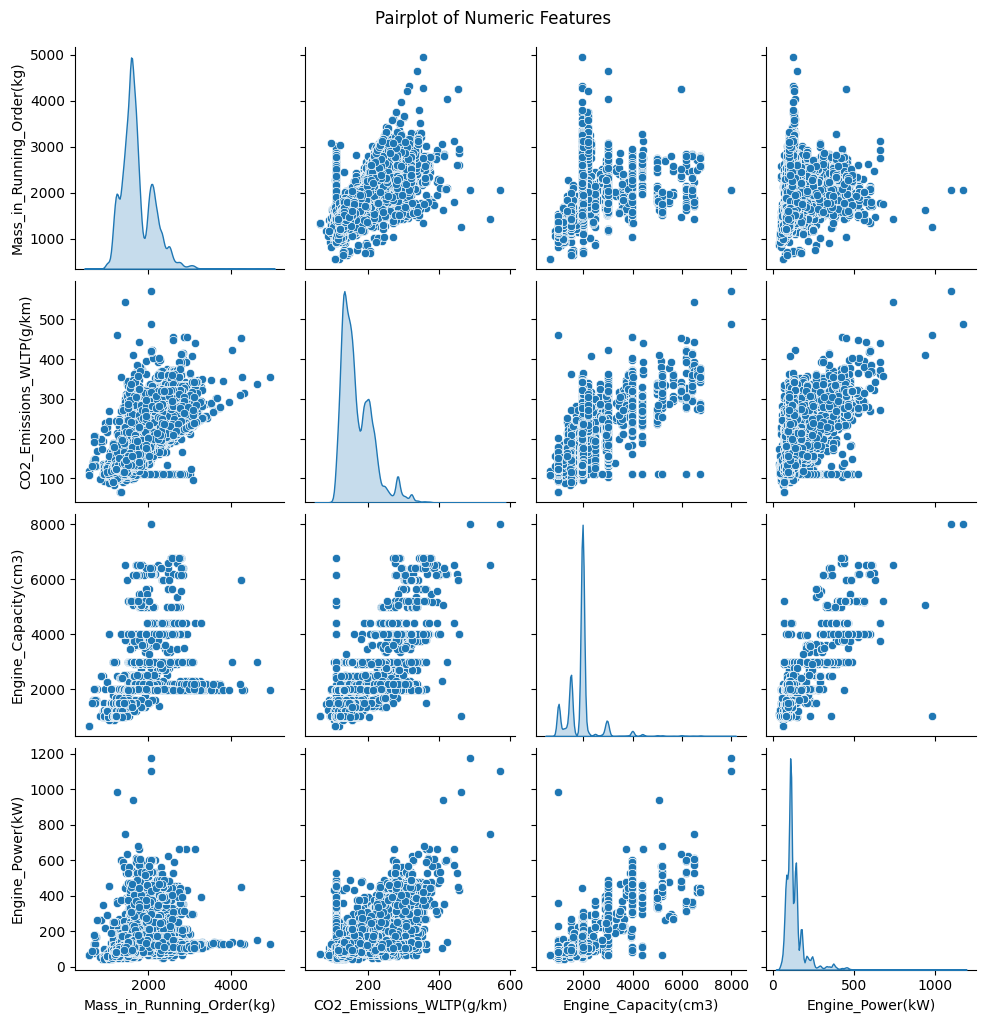

In [21]:
# Optional: Reduce number of samples if dataset is large
sns.pairplot(EEA, diag_kind='kde')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()


Mass:
 - Distribution: Right-skewed (positive skew)
 - Observations:
    - Clustered around 1000–2000 kg
    - Long tail to heavier vehicles (>2000 kg)
    - Likely outliers in the upper range

Engine capacity: 
  - Distribution: Right-skewed, but not heavily
  - Observations:
    - Looks like it has discrete bands. This is because vehicles share the exact same engine size due to the design norms, even though it’s a continuous variable
    - Clustering around typical engine sizes (1000, 1600, 2000, 3000 cm³)
    - Gaps between these clusters — not a smooth histogram

Engine_Power(kW):
  - Distribution: Heavily right skweed
  - Observations: 
    - Most vehicles are in the 50–150 kW range
    - Extreme outliers above 300–400 kW (likely high-performance cars)
    - These outliers will influence most models

 CO2_Emissions_WLTP(g/km):
  - Distribution: Also right-skewed
  - Observations:
    - Many vehicles emit between 100–200 g/km
    - Some go well above 250–300 g/km












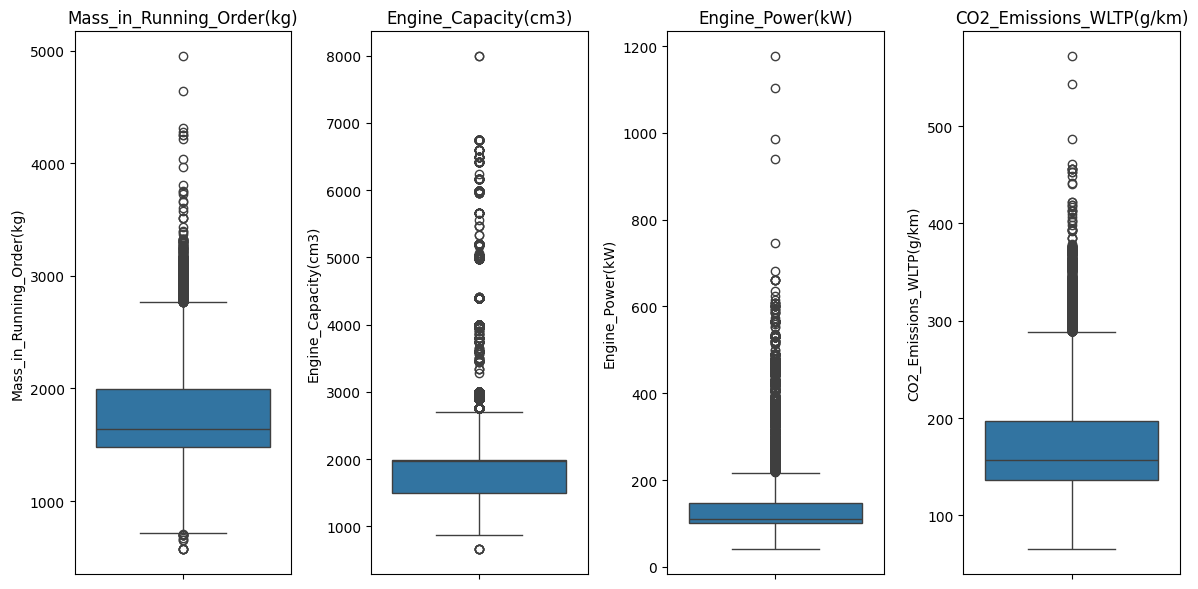

In [22]:

numeric_cols = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 
                'Engine_Power(kW)', 'CO2_Emissions_WLTP(g/km)']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=EEA[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

### What does the Fuel type distribution look like?

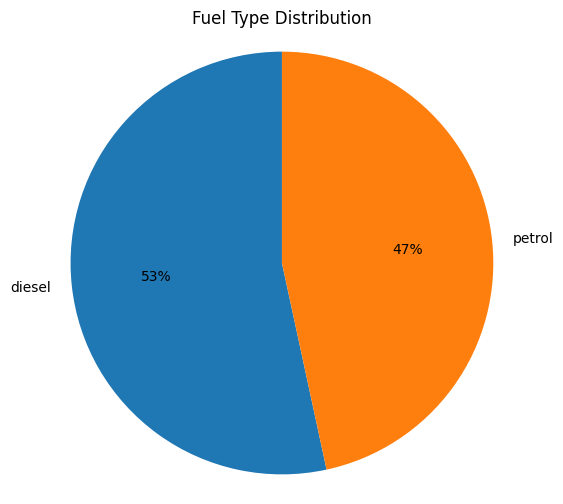

In [23]:

# Get value counts
fuel_counts = EEA['Fuel_Type'].value_counts(normalize=True)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.0f%%', startangle=90)
plt.title('Fuel Type Distribution')
plt.axis('equal')  # Makes the pie chart a circle
plt.show()

Let's explore how our variables are explaining our target

## Categorical into dummies

In [5]:
EEA = pd.get_dummies(EEA, columns=['Fuel_Type'], drop_first=True)

In [6]:
EEA = EEA.astype(int)

In [7]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
0,1175,129,999,70,1
1,1122,117,999,59,1
2,1588,126,1968,110,0
3,1516,124,1968,110,0
4,1349,126,1498,110,1


In [8]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75530 entries, 0 to 75529
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Mass_in_Running_Order(kg)  75530 non-null  int64
 1   CO2_Emissions_WLTP(g/km)   75530 non-null  int64
 2   Engine_Capacity(cm3)       75530 non-null  int64
 3   Engine_Power(kW)           75530 non-null  int64
 4   Fuel_Type_petrol           75530 non-null  int64
dtypes: int64(5)
memory usage: 2.9 MB


## Model 1 - RandomForestRegressor - great results, but low interpretability

Taking onto account the skewed distributions and have a lot of outliers, we would want to use these options:
 - RandomForestRegressor
 - GradientBoostingRegressor
 - XGBoost

These models do not require scaling or normalization

Test MSE: 131.69
Test MAE: 4.96
Test RMSE: 11.48
Test R² Score: 0.93


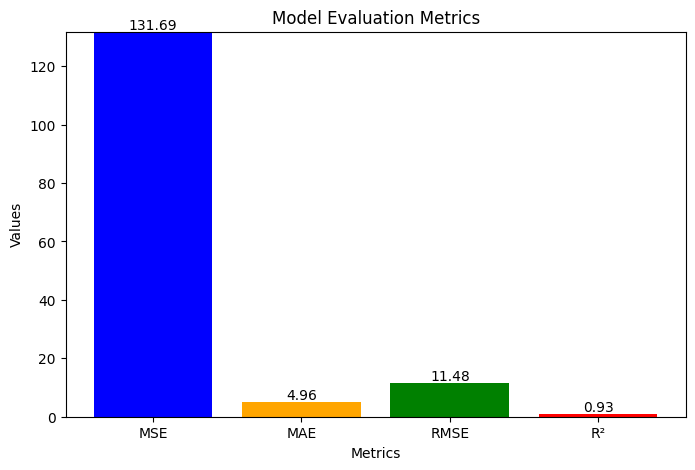

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Define features and target
X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

# 2. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make predictions
y_pred = rf_model.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mrse = np.sqrt(mse)  # Root Mean Squared Error

r2 = r2_score(y_test, y_pred)

# Print Evaluation Metrics
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {mrse:.2f}")
print(f"Test R² Score: {r2:.2f}")

# 6. Visualize the metrics on a graph
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, mrse, r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust the y-axis for better readability (e.g., for R²)
plt.ylim([0, max(values) + 0.1])

# Display the value labels above the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

# Show plot
plt.show()

R² score of 0.93 is very good, because it means that the model can explain 93% of the data variance. 
The MSE of 131.69, so the RMSE is 11.48 g/km, this means that on average, your model's prediction is  around 11.5 g/km or 6% off from the true CO₂ emission value. 

These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

Train MSE: 62.32
Test MSE: 131.69
Train MAE: 3.97
Test MAE: 4.96
Train RMSE: 7.89
Test RMSE: 11.48
Train R² Score: 0.97
Test R² Score: 0.93


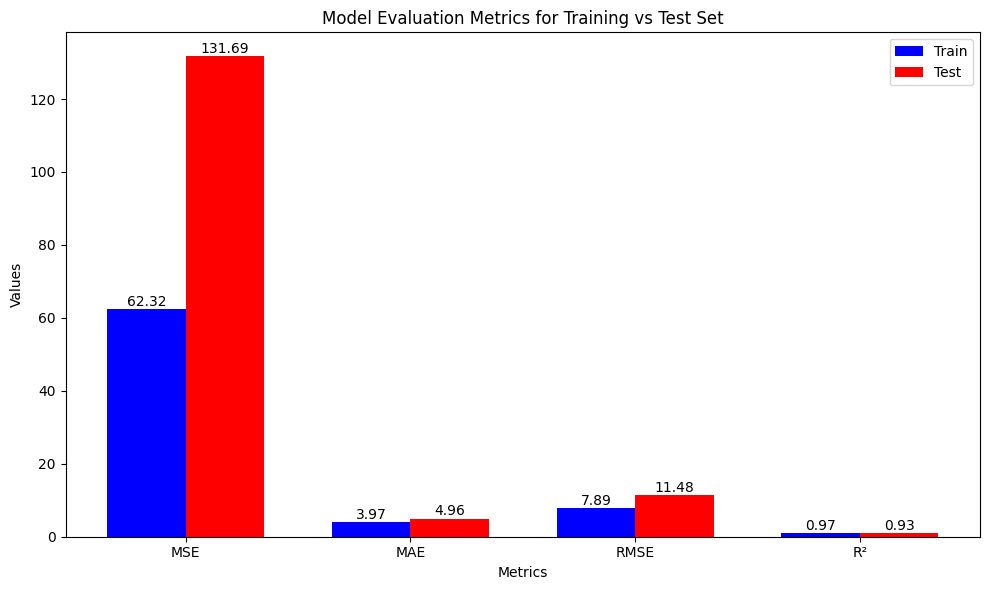

In [10]:
# 1. Predictions for Training and Test Set
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 2. Calculate MSE, MAE, RMSE, and R² for Training and Test Set
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mrse = np.sqrt(train_mse)
test_mrse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 3. Print Evaluation Metrics
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_mrse:.2f}")
print(f"Test RMSE: {test_mrse:.2f}")
print(f"Train R² Score: {train_r2:.2f}")
print(f"Test R² Score: {test_r2:.2f}")

# 4. Create a graph to compare metrics for Training vs Test set
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_mrse, train_r2]
test_values = [test_mse, test_mae, test_mrse, test_r2]

# Create the bar chart
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Display the values on top of the bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

The training set has very low MSE, MAE, and RMSE, indicating the model fits the training data well, while the R² score of 0.96 shows it explains 96% of the variance in the training set.
The test set shows slightly higher MSE, MAE, and especially in RMSE values, and the R² score is 0.93, suggesting that the model generalizes well but may still be overfitting slightly to the training data.

In oder to get a higher confidence in our results, we perform a cross-validation

In [11]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.2f}")

Cross-validated R² scores: [0.96791303 0.9610154  0.95873973 0.88731239 0.86414979]
Mean CV R² score: 0.93


- Slightly inconsistent performance: Scores range from 0.864 to 0.968 and the last two CV folds (0.887, 0.864) are significantly lower than the others. This suggests model's performance is unstable across different data splits.

- No severe overfitting:
    Test R² (0.93), train R² (0.97), and CV R² (0.93) are all close. The R² difference (0.04) is acceptable and suggests minimal overfitting.

- Model status: The overall performance of the model is strong. However, more stability and generalization improvement is needed. 

We will focus on reducing variance rather than improving average performance

#### Hyperparameter Tuning


📊 STAGE 1: Randomized Search (Broad Exploration)
--------------------------------------------------
Parameter space size: 4800
Testing 50 random combinations...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best CV R²: 0.9359
Best parameters: {'n_estimators': 100, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}

📊 STAGE 2: Grid Search (Focused Optimization)
--------------------------------------------------
Focused grid around best parameters:
  n_estimators: [50, 100, 150]
  max_depth: [20, 25, None]
  min_samples_split: [13, 15, 17]
  min_samples_leaf: [1, 1, 3]
  max_features: ['log2']
  bootstrap: [False]
Testing 81 combinations...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Final Best CV R²: 0.9377
Final Best parameters: {'bootstrap': False, 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 17, 'n_estimators': 100}

📈 MODEL COMPARISON

📊 DETAILED COM

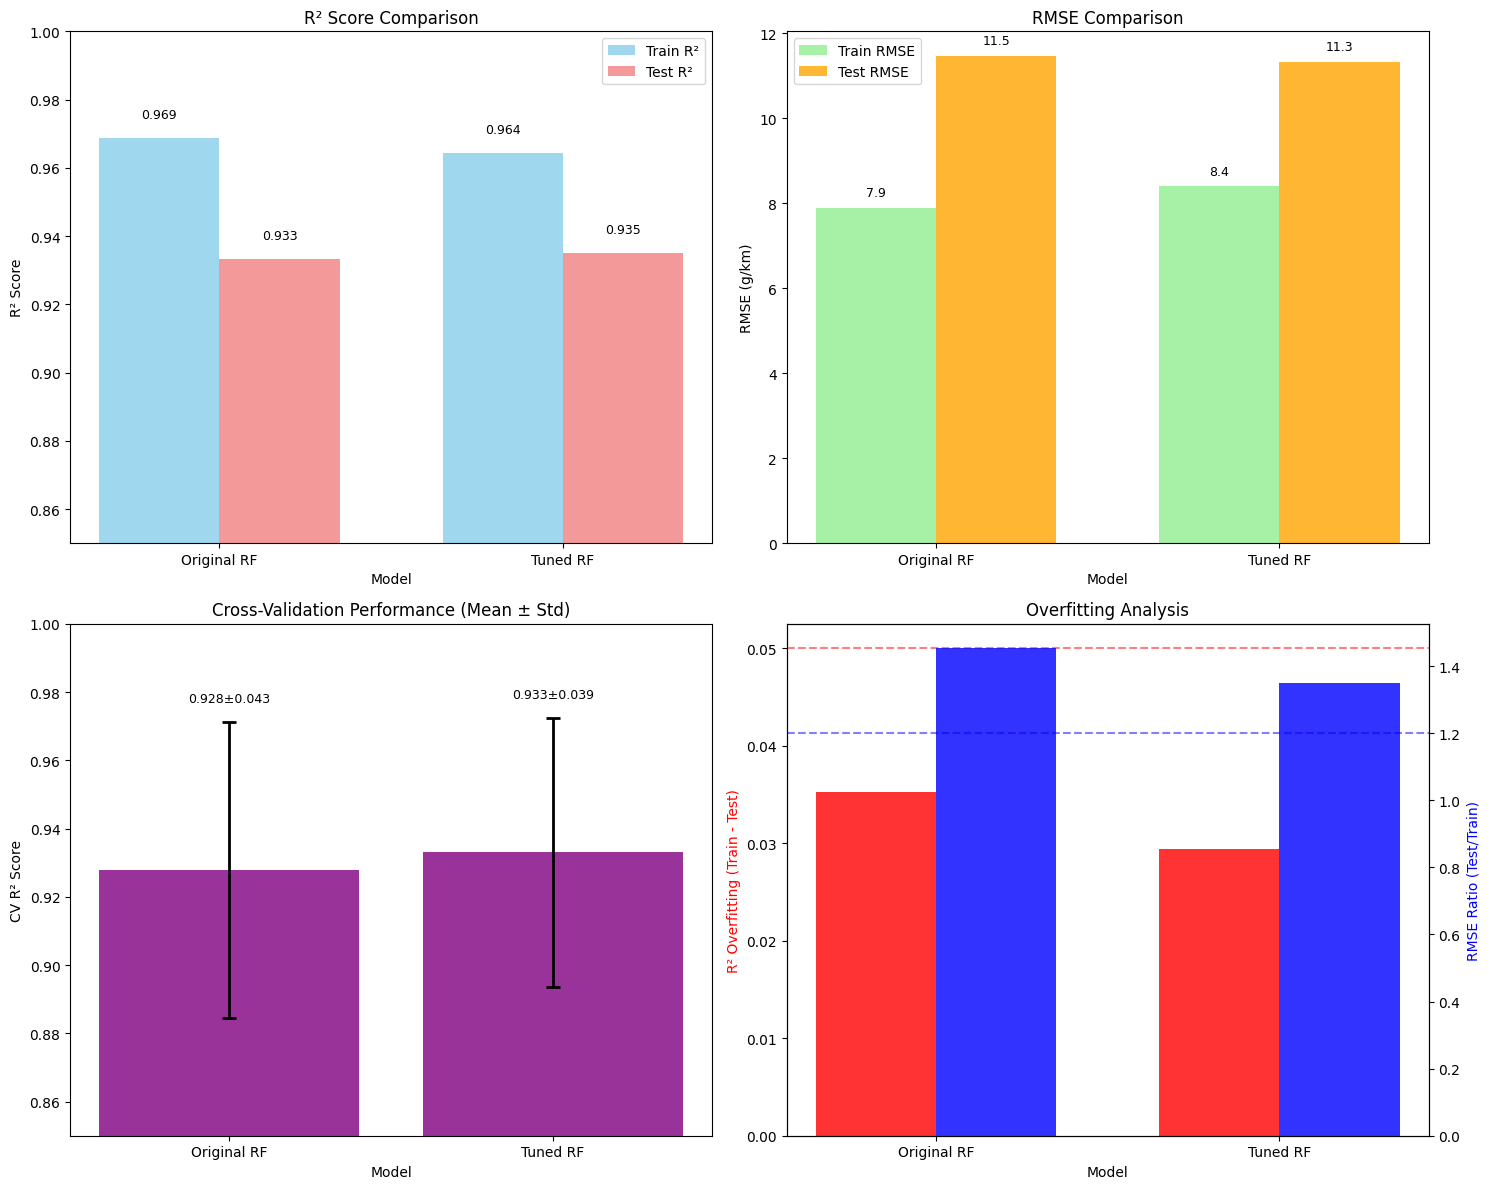


🎯 FINAL ANALYSIS
📊 IMPROVEMENT SUMMARY:
   CV R² improvement: +0.0052
   CV stability improvement: +0.0038
   Overfitting reduction: +0.0058

🔧 BEST HYPERPARAMETERS:
   bootstrap: False
   max_depth: 25
   max_features: log2
   min_samples_leaf: 1
   min_samples_split: 17
   n_estimators: 100

Best model saved as 'best_model_Random_Forest' variable


In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# STRATEGY: Two-Stage Hyperparameter Tuning
# Stage 1: RandomizedSearchCV (broad, fast exploration)
# Stage 2: GridSearchCV (focused, detailed optimization)


# Stage 1: RANDOMIZED SEARCH (Broad Exploration)
print("\n📊 STAGE 1: Randomized Search (Broad Exploration)")
print("-" * 50)

# Define broad parameter space
param_dist_stage1 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['sqrt', 'log2', 0.5, 0.7],
    'bootstrap': [True, False]
}

print("Parameter space size:", np.prod([len(v) for v in param_dist_stage1.values()]))
print("Testing 50 random combinations...")

# Initialize RandomizedSearchCV

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_stage1,
    n_iter=50,  # Test 50 random combinations
    cv=3,       # Reduced CV folds for speed
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit randomized search
random_search.fit(X_train, y_train)

print(f"Best CV R²: {random_search.best_score_:.4f}")
print(f"Best parameters: {random_search.best_params_}")

# Stage 2: GRID SEARCH (Focused Optimization)
print(f"\n📊 STAGE 2: Grid Search (Focused Optimization)")
print("-" * 50)

# Extract best parameters and create focused grid around them
best_params = random_search.best_params_

# Create focused parameter grid around best results
def create_focused_grid(best_params):
    grid = {}
    
    # n_estimators: ±50 around best value
    best_n_est = best_params['n_estimators']
    grid['n_estimators'] = [max(50, best_n_est-50), best_n_est, best_n_est+50]
    
    # max_depth: around best value
    best_depth = best_params['max_depth']
    if best_depth is None:
        grid['max_depth'] = [20, 25, None]
    else:
        grid['max_depth'] = [max(5, best_depth-5), best_depth, best_depth+5]
    
    # min_samples_split: around best value
    best_split = best_params['min_samples_split']
    grid['min_samples_split'] = [max(2, best_split-2), best_split, min(20, best_split+2)]
    
    # min_samples_leaf: around best value
    best_leaf = best_params['min_samples_leaf']
    grid['min_samples_leaf'] = [max(1, best_leaf-1), best_leaf, min(10, best_leaf+2)]
    
    # Keep best values for other parameters
    grid['max_features'] = [best_params['max_features']]
    grid['bootstrap'] = [best_params['bootstrap']]
    
    return grid

param_grid_stage2 = create_focused_grid(best_params)
print(f"Focused grid around best parameters:")
for param, values in param_grid_stage2.items():
    print(f"  {param}: {values}")

grid_combinations = np.prod([len(v) for v in param_grid_stage2.values()])
print(f"Testing {grid_combinations} combinations...")

# Initialize GridSearchCV

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_stage2,
    cv=5,  # Full CV for final selection
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train)

print(f"Final Best CV R²: {grid_search.best_score_:.4f}")
print(f"Final Best parameters: {grid_search.best_params_}")


# ============================================================================
# MODEL COMPARISON AND EVALUATION
# ============================================================================

print(f"\n📈 MODEL COMPARISON")
print("="*50)

# Original model
original_rf = RandomForestRegressor(n_estimators=100, random_state=42)
original_rf.fit(X_train, y_train)

# Best tuned model
best_rf = grid_search.best_estimator_



# Compare models
models = {
    'Original RF': original_rf,
    'Tuned RF': best_rf
}

results_comparison = []

for name, model in models.items():
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    results_comparison.append({
        'Model': name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'CV_R2_Mean': cv_scores.mean(),
        'CV_R2_Std': cv_scores.std(),
        'Overfitting': train_r2 - test_r2,
        'RMSE_Ratio': test_rmse / train_rmse
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(results_comparison)
print("\n📊 DETAILED COMPARISON:")
print(comparison_df.round(4).to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: R² Comparison
models_names = comparison_df['Model']
train_r2_vals = comparison_df['Train_R2']
test_r2_vals = comparison_df['Test_R2']

x = np.arange(len(models_names))
width = 0.35

axes[0,0].bar(x - width/2, train_r2_vals, width, label='Train R²', alpha=0.8, color='skyblue')
axes[0,0].bar(x + width/2, test_r2_vals, width, label='Test R²', alpha=0.8, color='lightcoral')
axes[0,0].set_xlabel('Model')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_title('R² Score Comparison')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models_names)
axes[0,0].legend()
axes[0,0].set_ylim([0.85, 1.0])

# Add values on bars
for i, (train_val, test_val) in enumerate(zip(train_r2_vals, test_r2_vals)):
    axes[0,0].text(i - width/2, train_val + 0.005, f'{train_val:.3f}', 
                   ha='center', va='bottom', fontsize=9)
    axes[0,0].text(i + width/2, test_val + 0.005, f'{test_val:.3f}', 
                   ha='center', va='bottom', fontsize=9)

# Plot 2: RMSE Comparison
train_rmse_vals = comparison_df['Train_RMSE']
test_rmse_vals = comparison_df['Test_RMSE']

axes[0,1].bar(x - width/2, train_rmse_vals, width, label='Train RMSE', alpha=0.8, color='lightgreen')
axes[0,1].bar(x + width/2, test_rmse_vals, width, label='Test RMSE', alpha=0.8, color='orange')
axes[0,1].set_xlabel('Model')
axes[0,1].set_ylabel('RMSE (g/km)')
axes[0,1].set_title('RMSE Comparison')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models_names)
axes[0,1].legend()

# Add values on bars
for i, (train_val, test_val) in enumerate(zip(train_rmse_vals, test_rmse_vals)):
    axes[0,1].text(i - width/2, train_val + 0.2, f'{train_val:.1f}', 
                   ha='center', va='bottom', fontsize=9)
    axes[0,1].text(i + width/2, test_val + 0.2, f'{test_val:.1f}', 
                   ha='center', va='bottom', fontsize=9)

# Plot 3: Cross-Validation Performance
cv_means = comparison_df['CV_R2_Mean']
cv_stds = comparison_df['CV_R2_Std']

axes[1,0].bar(models_names, cv_means, yerr=cv_stds, alpha=0.8, color='purple', 
              capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})
axes[1,0].set_xlabel('Model')
axes[1,0].set_ylabel('CV R² Score')
axes[1,0].set_title('Cross-Validation Performance (Mean ± Std)')
axes[1,0].set_ylim([0.85, 1.0])

# Add values on bars
for i, (mean_val, std_val) in enumerate(zip(cv_means, cv_stds)):
    axes[1,0].text(i, mean_val + std_val + 0.005, f'{mean_val:.3f}±{std_val:.3f}', 
                   ha='center', va='bottom', fontsize=9)

# Plot 4: Overfitting Analysis
overfitting_vals = comparison_df['Overfitting']
rmse_ratios = comparison_df['RMSE_Ratio']

# Dual y-axis plot
ax1 = axes[1,1]
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, overfitting_vals, width, alpha=0.8, color='red', 
                label='R² Overfitting')
bars2 = ax2.bar(x + width/2, rmse_ratios, width, alpha=0.8, color='blue', 
                label='RMSE Ratio')

ax1.set_xlabel('Model')
ax1.set_ylabel('R² Overfitting (Train - Test)', color='red')
ax2.set_ylabel('RMSE Ratio (Test/Train)', color='blue')
ax1.set_title('Overfitting Analysis')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names)

# Add reference lines
ax1.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='Overfitting Threshold')
ax2.axhline(y=1.2, color='blue', linestyle='--', alpha=0.5, label='RMSE Ratio Threshold')

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL ANALYSIS
# ============================================================================

print(f"\n🎯 FINAL ANALYSIS")
print("="*70)

# Determine which model is better
tuned_improvement = comparison_df[comparison_df['Model'] == 'Tuned RF']
original_performance = comparison_df[comparison_df['Model'] == 'Original RF']

cv_improvement = (tuned_improvement['CV_R2_Mean'].values[0] - 
                  original_performance['CV_R2_Mean'].values[0])
stability_improvement = (original_performance['CV_R2_Std'].values[0] - 
                        tuned_improvement['CV_R2_Std'].values[0])

print(f"📊 IMPROVEMENT SUMMARY:")
print(f"   CV R² improvement: {cv_improvement:+.4f}")
print(f"   CV stability improvement: {stability_improvement:+.4f}")
print(f"   Overfitting reduction: {original_performance['Overfitting'].values[0] - tuned_improvement['Overfitting'].values[0]:+.4f}")


print(f"\n🔧 BEST HYPERPARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")


# Save the best model for future use
best_model_Random_Forest = grid_search.best_estimator_
print(f"\nBest model saved as 'best_model_Random_Forest' variable")

In [13]:
cv_scores_best = cross_val_score(best_model_Random_Forest, X, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores_best}")
print(f"Mean CV R² score: {cv_scores_best.mean():.2f}")

Cross-validated R² scores: [0.9704326  0.96459833 0.95914715 0.8944507  0.87638793]
Mean CV R² score: 0.93


In [14]:
## Base RF model evaluation

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.2f}")

Cross-validated R² scores: [0.96791303 0.9610154  0.95873973 0.88731239 0.86414979]
Mean CV R² score: 0.93


We observe slight improvement with hyperparameter optimization on CV R2 scores even though it didn't eliminate the existing (slight) overfitting situation completely.

## Model 2 - Linear Regression

In [34]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])



Train MSE (LR): 364.62
Test MSE (LR): 373.25
Train MAE (LR): 12.03
Test MAE (LR): 12.02
Train RMSE (LR): 19.10
Test RMSE (LR): 19.32
Train R² Score (LR): 0.82
Test R² Score (LR): 0.81


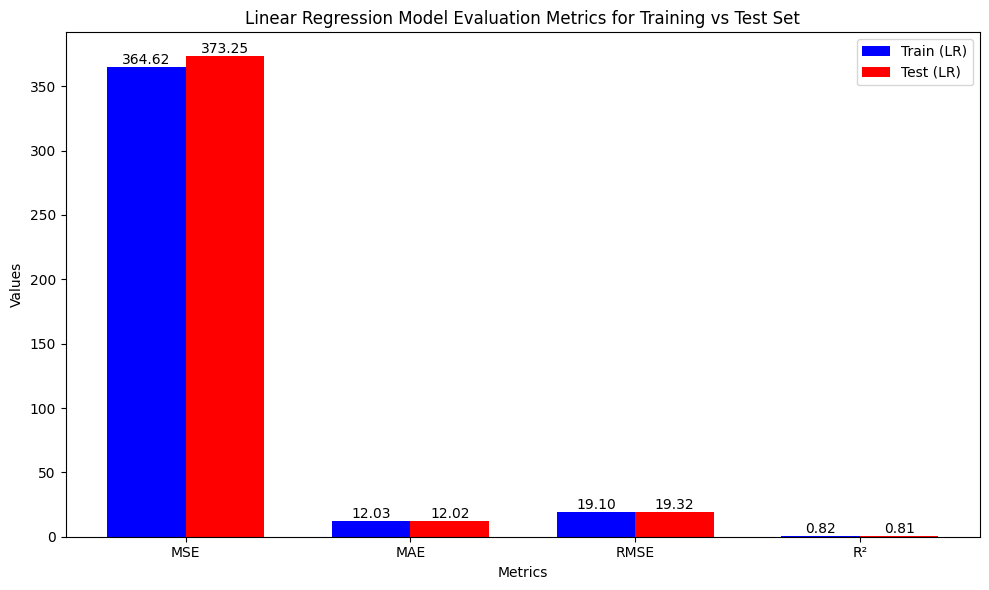

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

lr_model_scaled = LinearRegression()
lr_model_scaled.fit(X_train_scaled, y_train)

y_train_pred_lr = lr_model_scaled.predict(X_train_scaled)
y_test_pred_lr = lr_model_scaled.predict(X_test_scaled)

train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)

train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

train_mrse_lr = np.sqrt(train_mse_lr)
test_mrse_lr = np.sqrt(test_mse_lr)

train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print(f"Train MSE (LR): {train_mse_lr:.2f}")
print(f"Test MSE (LR): {test_mse_lr:.2f}")
print(f"Train MAE (LR): {train_mae_lr:.2f}")
print(f"Test MAE (LR): {test_mae_lr:.2f}")
print(f"Train RMSE (LR): {train_mrse_lr:.2f}")
print(f"Test RMSE (LR): {test_mrse_lr:.2f}")
print(f"Train R² Score (LR): {train_r2_lr:.2f}")
print(f"Test R² Score (LR): {test_r2_lr:.2f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values_lr = [train_mse_lr, train_mae_lr, train_mrse_lr, train_r2_lr]
test_values_lr = [test_mse_lr, test_mae_lr, test_mrse_lr, test_r2_lr]

bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values_lr, bar_width, label='Train (LR)', color='blue')
plt.bar(index + bar_width, test_values_lr, bar_width, label='Test (LR)', color='red')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Linear Regression Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

for i, value in enumerate(train_values_lr):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values_lr):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    37.240262
3           Fuel_Type_petrol    22.820005
2           Engine_Power(kW)    10.870419
1       Engine_Capacity(cm3)     0.912619


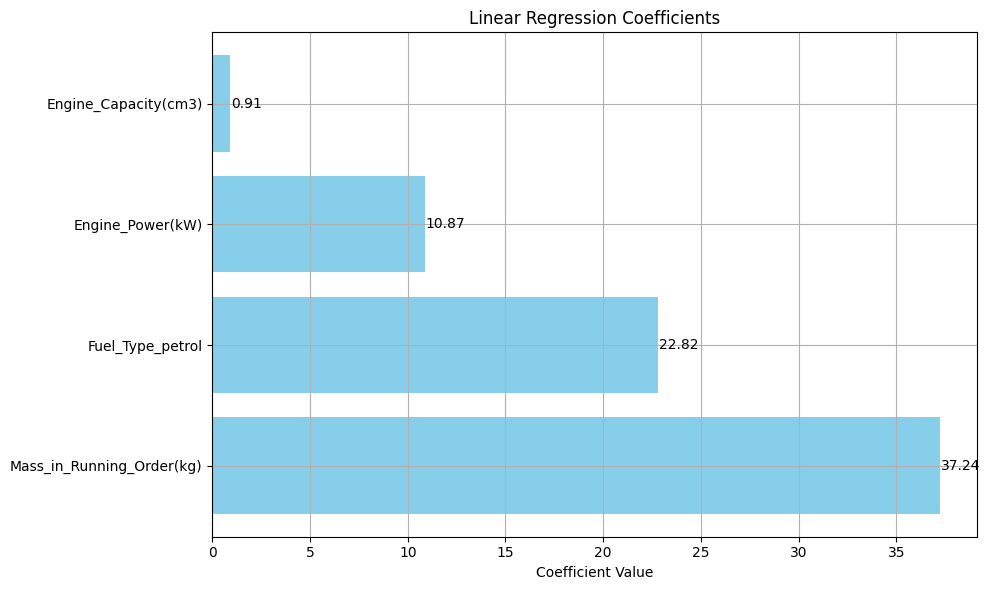

In [38]:
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model_scaled.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

# Plotting the coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients')

# Adding the coefficient values on the bars
for i, v in enumerate(coefficients['Coefficient']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', ha='left', color='black')

plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
train_test_diff = abs(train_r2_lr - test_r2_lr)
print(f"Train R²: {train_r2_lr:.3f}")
print(f"Test R²: {test_r2_lr:.3f}")
print(f"R² Difference: {train_test_diff:.3f}")

if train_test_diff > 0.05:
    print("⚠️  Potential overfitting detected")
elif test_r2_lr > train_r2_lr:
    print("✅ No overfitting - good generalization")
else:
    print("✅ Good fit - minimal overfitting")

Train R²: 0.816
Test R²: 0.811
R² Difference: 0.005
✅ Good fit - minimal overfitting


- R² Score: 0.81
    - This means 81% of the variance in CO₂ emissions is explained by the model. That’s a strong result for a linear model, especially considering the simplicity and interpretability.

- MSE: 373.25

    - The root of Mean Squared Error is 19.3, so the model predicts around 12% off the actual value, this MSE seems reasonable.

The model generalizes well and isn't heavily overfitting as the R2 difference is 0.005.

- Mass_in_Running_Order is the Strongest predictor. Heavier vehicles emit more CO₂
- The next strongest predictor is Fuel_Type_petrol. Petrol cars emit significantly more than diesel (since "petrol = 1")
- The weakest impact is the Engine_Capacity(cm3), which indicates that might be redundant with power or mass

## Model 3 - Lasso model

In [40]:
from sklearn.linear_model import Lasso

In [41]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
scaler = StandardScaler()
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])


In [44]:
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


Lasso Test MSE: 373.32
Lasso Test MAE: 12.02
Lasso Test RMSE: 19.32
Lasso Test R²: 0.81


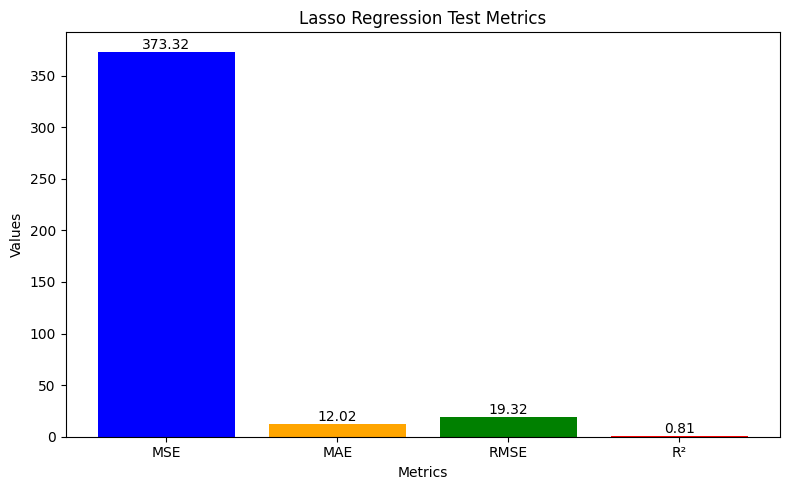

In [45]:
y_pred = lasso_model.predict(X_test_scaled)

# Calculate MSE, MAE, RMSE, and R²
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mrse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print Evaluation Metrics
print(f"Lasso Test MSE: {mse:.2f}")
print(f"Lasso Test MAE: {mae:.2f}")
print(f"Lasso Test RMSE: {mrse:.2f}")
print(f"Lasso Test R²: {r2:.2f}")

# Prepare data for the graph
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, mrse, r2]

# Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])

# Add the values on top of the bars
for i, value in enumerate(values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Lasso Regression Test Metrics')

# Show the graph
plt.tight_layout()
plt.show()

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    36.971072
3           Fuel_Type_petrol    21.985693
2           Engine_Power(kW)    11.147560
1       Engine_Capacity(cm3)     0.661750


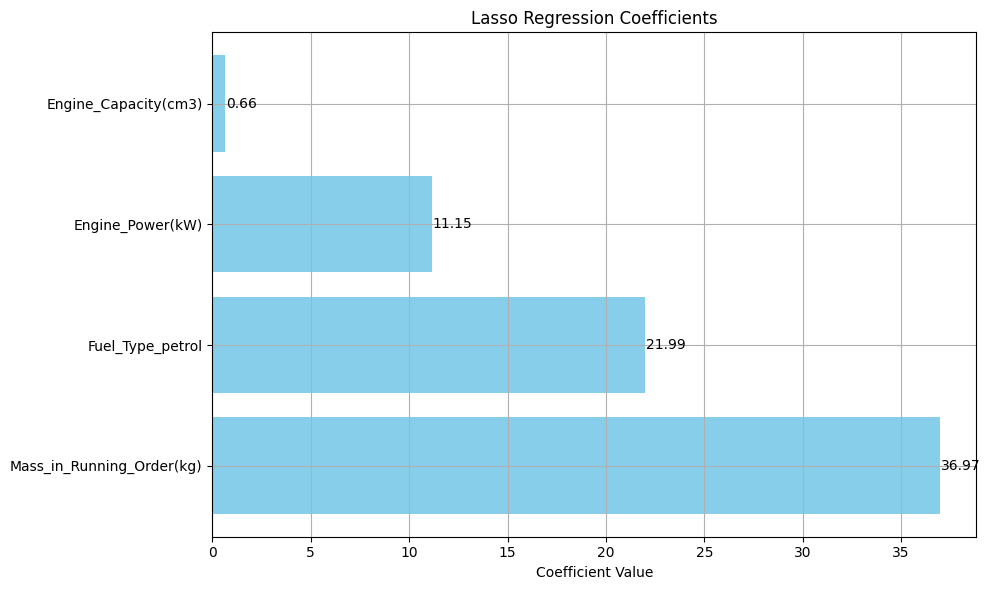

In [46]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

# Plotting the coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')

# Adding the coefficient values on the bars
for i, v in enumerate(coefficients['Coefficient']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', ha='left', color='black')

plt.xlabel('Coefficient Value')
plt.title('Lasso Regression Coefficients')
plt.grid(True)
plt.tight_layout()
plt.show()

Best alpha: 0.0012648552168552957
Test MSE: 373.25029880160594
Lasso Test RMSE: 19.32
Test R²: 0.8111775248805911


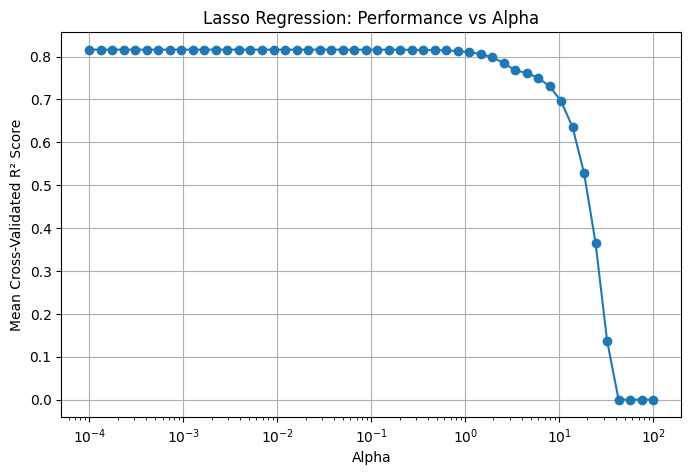

In [47]:
from sklearn.model_selection import train_test_split, GridSearchCV

# 4. Define Lasso model and alpha grid
lasso = Lasso(max_iter=10000)
alphas = {'alpha': np.logspace(-4, 2, 50)}  # alpha values from 0.0001 to 100

# 5. Grid search for best alpha
grid = GridSearchCV(lasso, alphas, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

# 6. Best model evaluation
best_lasso = grid.best_estimator_
y_pred = best_lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mrse = np.sqrt(mse)

print("Best alpha:", grid.best_params_['alpha'])
print("Test MSE:", mse)
print(f"Lasso Test RMSE: {mrse:.2f}")
print("Test R²:", r2)

# 7. Plot alpha vs CV R²
plt.figure(figsize=(8, 5))
plt.semilogx(alphas['alpha'], grid.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Alpha')
plt.ylabel('Mean Cross-Validated R² Score')
plt.title('Lasso Regression: Performance vs Alpha')
plt.grid(True)
plt.show()



The results are very similar to Linear Model above.

## Model 4 - XGboost model

In [48]:
import xgboost as xgb

In [49]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
scaler = StandardScaler()
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

Basic Model Performance:
MSE: 154.448
RMSE: 12.428
R² Score: 0.922
MAE: 6.140


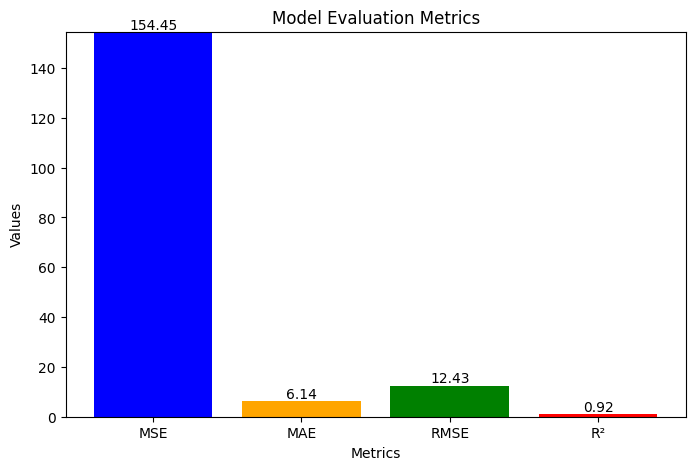

In [55]:
xgb_basic = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

xgb_basic.fit(X_train_scaled, y_train)
y_pred_basic = xgb_basic.predict(X_test_scaled)

# Basic model evaluation
mse_basic = mean_squared_error(y_test, y_pred_basic)
rmse_basic = np.sqrt(mean_squared_error(y_test, y_pred_basic))
r2_basic = r2_score(y_test, y_pred_basic)
mae_basic = mean_absolute_error(y_test, y_pred_basic)


print(f"Basic Model Performance:")
print(f"MSE: {mse_basic:.3f}")
print(f"RMSE: {rmse_basic:.3f}")
print(f"R² Score: {r2_basic:.3f}")
print(f"MAE: {mae_basic:.3f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse_basic, mae_basic, rmse_basic, r2_basic]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust the y-axis for better readability (e.g., for R²)
plt.ylim([0, max(values) + 0.1])

# Display the value labels above the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

# Show plot
plt.show()



R² score of 0.92 is very good, because it means that the model can explain 92% of the data variance. 

These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

Train MSE: 105.57
Test MSE: 154.45
Train MAE: 5.71
Test MAE: 6.14
Train RMSE: 10.27
Test RMSE: 12.43
Train R² Score: 0.95
Test R² Score: 0.92


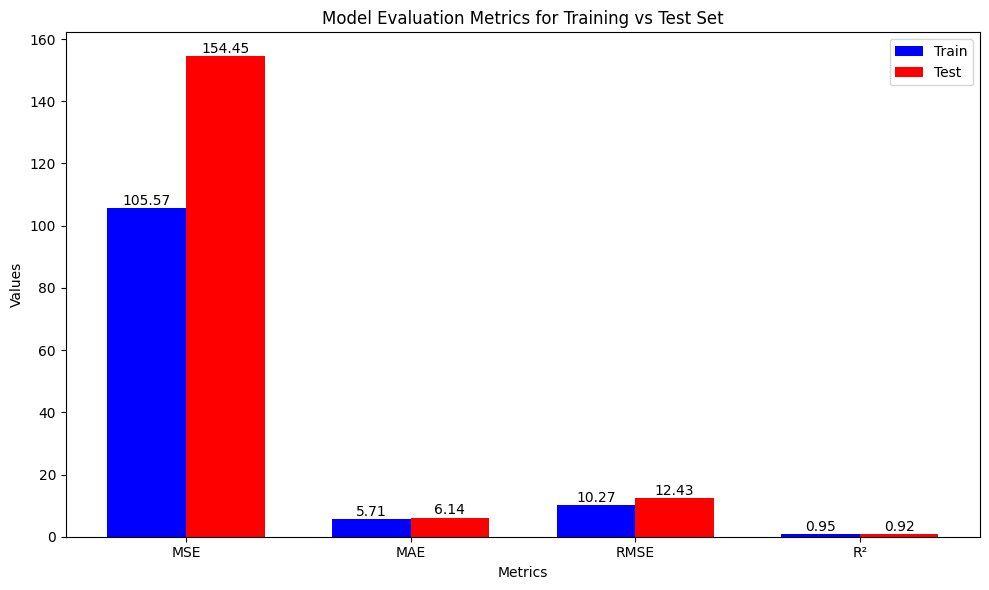

In [54]:
# 1. Predictions for Training and Test Set
y_train_pred = xgb_basic.predict(X_train_scaled)
y_test_pred = xgb_basic.predict(X_test_scaled)

# 2. Calculate MSE, MAE, RMSE, and R² for Training and Test Set
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mrse = np.sqrt(train_mse)
test_mrse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 3. Print Evaluation Metrics
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_mrse:.2f}")
print(f"Test RMSE: {test_mrse:.2f}")
print(f"Train R² Score: {train_r2:.2f}")
print(f"Test R² Score: {test_r2:.2f}")

# 4. Create a graph to compare metrics for Training vs Test set
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_mrse, train_r2]
test_values = [test_mse, test_mae, test_mrse, test_r2]

# Create the bar chart
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Display the values on top of the bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

The training set has very low MSE, MAE, and RMSE, indicating the model fits the training data well, while the R² score of 0.95 shows it explains 95% of the variance in the training set.
The test set shows slightly higher MSE, MAE, and especially in RMSE values, and the R² score is 0.92, suggesting that the model generalizes well but may still be overfitting slightly to the training data.

- The model captures the underlying relationship between vehicle characteristics and CO2 emissions very well
- Performance is consistent between training and test sets (no severe overfitting)
- Error levels are practically acceptable for most applications

However, The mild overfitting suggests hyperparameter tuning could help

In [56]:
cv_scores = cross_val_score(xgb_basic, X, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.2f}")

Cross-validated R² scores: [0.96177119 0.95386308 0.94961601 0.87808132 0.86469686]
Mean CV R² score: 0.92


We see very similar pattern as Random Forest Model results. 

More stability and generalization improvement is needed. 

Therefore; We will focus on reducing variance rather than improving average performance

#### Hyperparameter Tuning


=== Hyperparameter Tuning ===
Fitting 5 folds for each of 1458 candidates, totalling 7290 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 10, 'reg_lambda': 1, 'subsample': 0.9}
Best CV score: 12.505

=== Best Model Performance ===
RMSE: 13.026
R² Score: 0.914
MAE: 7.067

=== Feature Importance ===
                     feature  importance
0  Mass_in_Running_Order(kg)    0.562454
3           Fuel_Type_petrol    0.181649
2           Engine_Power(kW)    0.136909
1       Engine_Capacity(cm3)    0.118987

📈 MODEL COMPARISON

📊 DETAILED COMPARISON:
        Model  Train_R2  Test_R2  Train_RMSE  Test_RMSE  CV_R2_Mean  CV_R2_Std  Overfitting  RMSE_Ratio
    Basic XGB    0.9468   0.9219     10.2749    12.4277      0.9216     0.0414       0.0250      1.2095
FineTuned XGB    0.9309   0.9142     11.7167    13.0261      0.9155     0.0375       0.0167      1.1118


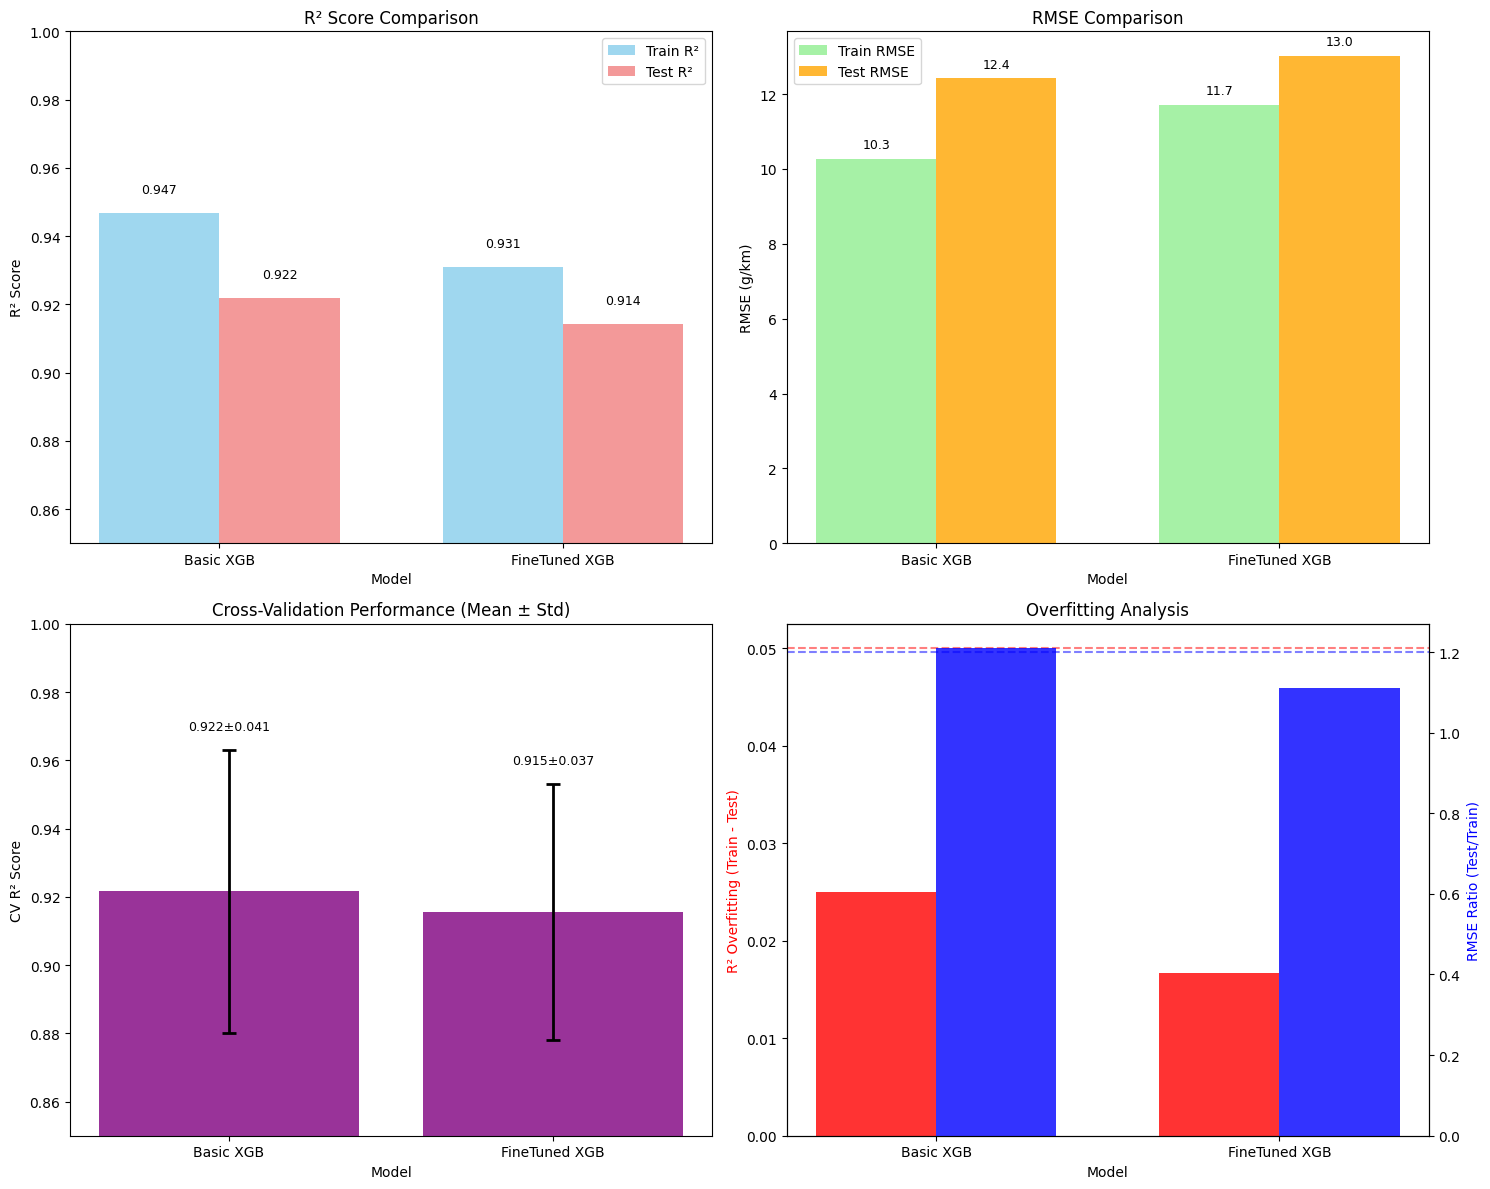


🎯 FINAL ANALYSIS
📊 IMPROVEMENT SUMMARY:
   CV R² improvement: -0.0061
   CV stability improvement: +0.0039
   Overfitting reduction: +0.0083

Best model saved as 'best_model_XGBoost' variable


In [62]:

print("\n=== Hyperparameter Tuning ===")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'reg_alpha': [0.1, 1, 10],
    'reg_lambda': [1, 10, 100],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_grid = xgb.XGBRegressor(random_state=42, eval_metric='rmse')
grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {-grid_search.best_score_:.3f}")

# 3. Best Model Performance
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_scaled)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)

print(f"\n=== Best Model Performance ===")
print(f"RMSE: {rmse_best:.3f}")
print(f"R² Score: {r2_best:.3f}")
print(f"MAE: {mae_best:.3f}")

# 4. Feature Importance Analysis
print("\n=== Feature Importance ===")
feature_importance = best_xgb.feature_importances_
feature_names = X_train_scaled.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df)




print(f"\n📈 MODEL COMPARISON")
print("="*50)


models = {
    'Basic XGB': xgb_basic,
    'FineTuned XGB': best_xgb
}

results_comparison = []

for name, model in models.items():
    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    results_comparison.append({
        'Model': name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'CV_R2_Mean': cv_scores.mean(),
        'CV_R2_Std': cv_scores.std(),
        'Overfitting': train_r2 - test_r2,
        'RMSE_Ratio': test_rmse / train_rmse
    })


# Create comparison DataFrame
comparison_df = pd.DataFrame(results_comparison)
print("\n📊 DETAILED COMPARISON:")
print(comparison_df.round(4).to_string(index=False))


# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: R² Comparison
models_names = comparison_df['Model']
train_r2_vals = comparison_df['Train_R2']
test_r2_vals = comparison_df['Test_R2']

x = np.arange(len(models_names))
width = 0.35

axes[0,0].bar(x - width/2, train_r2_vals, width, label='Train R²', alpha=0.8, color='skyblue')
axes[0,0].bar(x + width/2, test_r2_vals, width, label='Test R²', alpha=0.8, color='lightcoral')
axes[0,0].set_xlabel('Model')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_title('R² Score Comparison')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models_names)
axes[0,0].legend()
axes[0,0].set_ylim([0.85, 1.0])

# Add values on bars
for i, (train_val, test_val) in enumerate(zip(train_r2_vals, test_r2_vals)):
    axes[0,0].text(i - width/2, train_val + 0.005, f'{train_val:.3f}', 
                   ha='center', va='bottom', fontsize=9)
    axes[0,0].text(i + width/2, test_val + 0.005, f'{test_val:.3f}', 
                   ha='center', va='bottom', fontsize=9)

# Plot 2: RMSE Comparison
train_rmse_vals = comparison_df['Train_RMSE']
test_rmse_vals = comparison_df['Test_RMSE']

axes[0,1].bar(x - width/2, train_rmse_vals, width, label='Train RMSE', alpha=0.8, color='lightgreen')
axes[0,1].bar(x + width/2, test_rmse_vals, width, label='Test RMSE', alpha=0.8, color='orange')
axes[0,1].set_xlabel('Model')
axes[0,1].set_ylabel('RMSE (g/km)')
axes[0,1].set_title('RMSE Comparison')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models_names)
axes[0,1].legend()

# Add values on bars
for i, (train_val, test_val) in enumerate(zip(train_rmse_vals, test_rmse_vals)):
    axes[0,1].text(i - width/2, train_val + 0.2, f'{train_val:.1f}', 
                   ha='center', va='bottom', fontsize=9)
    axes[0,1].text(i + width/2, test_val + 0.2, f'{test_val:.1f}', 
                   ha='center', va='bottom', fontsize=9)

# Plot 3: Cross-Validation Performance
cv_means = comparison_df['CV_R2_Mean']
cv_stds = comparison_df['CV_R2_Std']

axes[1,0].bar(models_names, cv_means, yerr=cv_stds, alpha=0.8, color='purple', 
              capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})
axes[1,0].set_xlabel('Model')
axes[1,0].set_ylabel('CV R² Score')
axes[1,0].set_title('Cross-Validation Performance (Mean ± Std)')
axes[1,0].set_ylim([0.85, 1.0])

# Add values on bars
for i, (mean_val, std_val) in enumerate(zip(cv_means, cv_stds)):
    axes[1,0].text(i, mean_val + std_val + 0.005, f'{mean_val:.3f}±{std_val:.3f}', 
                   ha='center', va='bottom', fontsize=9)

# Plot 4: Overfitting Analysis
overfitting_vals = comparison_df['Overfitting']
rmse_ratios = comparison_df['RMSE_Ratio']

# Dual y-axis plot
ax1 = axes[1,1]
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, overfitting_vals, width, alpha=0.8, color='red', 
                label='R² Overfitting')
bars2 = ax2.bar(x + width/2, rmse_ratios, width, alpha=0.8, color='blue', 
                label='RMSE Ratio')

ax1.set_xlabel('Model')
ax1.set_ylabel('R² Overfitting (Train - Test)', color='red')
ax2.set_ylabel('RMSE Ratio (Test/Train)', color='blue')
ax1.set_title('Overfitting Analysis')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names)

# Add reference lines
ax1.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='Overfitting Threshold')
ax2.axhline(y=1.2, color='blue', linestyle='--', alpha=0.5, label='RMSE Ratio Threshold')

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL ANALYSIS
# ============================================================================

print(f"\n🎯 FINAL ANALYSIS")
print("="*70)

# Determine which model is better
tuned_improvement = comparison_df[comparison_df['Model'] == 'FineTuned XGB']
original_performance = comparison_df[comparison_df['Model'] == 'Basic XGB']

cv_improvement = (tuned_improvement['CV_R2_Mean'].values[0] - 
                  original_performance['CV_R2_Mean'].values[0])
stability_improvement = (original_performance['CV_R2_Std'].values[0] - 
                        tuned_improvement['CV_R2_Std'].values[0])

print(f"📊 IMPROVEMENT SUMMARY:")
print(f"   CV R² improvement: {cv_improvement:+.4f}")
print(f"   CV stability improvement: {stability_improvement:+.4f}")
print(f"   Overfitting reduction: {original_performance['Overfitting'].values[0] - tuned_improvement['Overfitting'].values[0]:+.4f}")


# Save the best model for future use
best_model_XGBoost = grid_search.best_estimator_
print(f"\nBest model saved as 'best_model_XGBoost' variable")

In [63]:
cv_scores = cross_val_score(xgb_basic, X, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.2f}")

Cross-validated R² scores: [0.96177119 0.95386308 0.94961601 0.87808132 0.86469686]
Mean CV R² score: 0.92


In [64]:
cv_scores = cross_val_score(best_xgb, X, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.2f}")

Cross-validated R² scores: [0.95343226 0.94525224 0.93806243 0.87764245 0.86301434]
Mean CV R² score: 0.92


We have seen a slight overfitting reduction after hyperparameter tuning, but that also costs us some performance degradation. 


## Model Comparison Conclusion


When we compare the Random Forest and XGBoost then we see that Random Forest model's performance is slightly better than XGBoost. Therefore, we will proceed next steps with Random Forest model

| Metric       | XGBoost | Random Forest | Winner                           |
| ------------ | ------- | ------------- | -------------------------------- |
| **RMSE**     | 13.026  | 11.336        | 🏆**Random Forest** (-1.69 g/km) |
| **R² Score** | 0.914   | 0.935         | 🏆 **Random Forest** (+0.021)    |

Random Forest shows:

- 13% lower prediction error (RMSE improvement)
- 2.1% higher variance explained (R² improvement)

### SHAP Values

In [15]:
import shap

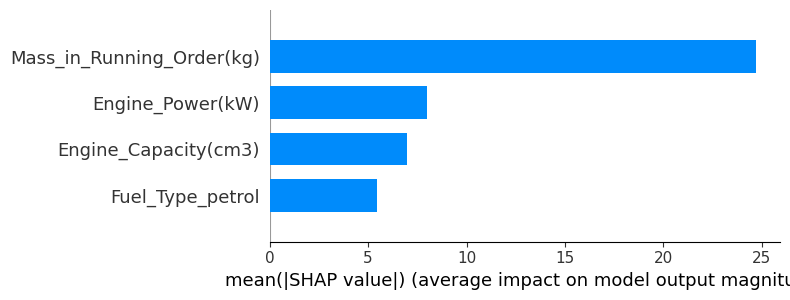

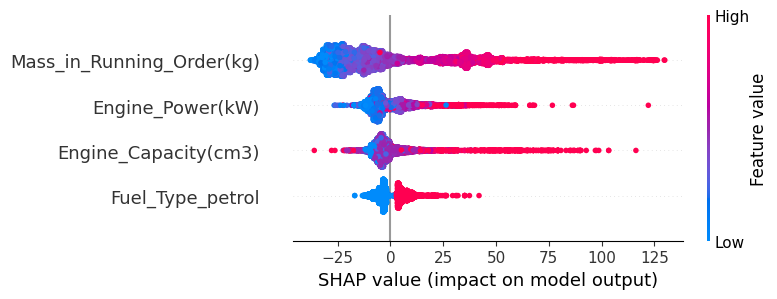

In [19]:
model = best_model_Random_Forest  

# 2. Create a SHAP explainer for your Random Forest model
explainer = shap.TreeExplainer(model)

# 3. Calculate SHAP values for your test data
shap_values = explainer.shap_values(X_test)

# 4. Plot a summary of feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

# 5. Plot a detailed summary (shows feature impact direction)
shap.summary_plot(shap_values, X_test)
plt.show()